# Model Testing with different Base learners

In [ ]:
import os
import sys
print(os.getcwd())
sys.path.append(os.path.abspath(".."))
from utils import scale_continuous_by_group, process_data, rf_cv, xgbc_cv, xgb_reg, classification_metrics, regression_metrics, cast_params, test_prediction, rf_reg, extract_metrics
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
import numpy as np
import pandas as pd
from inference import HierarchicalClassifier, HierarchicalRegressor
import joblib
from sklearn.model_selection import LeaveOneGroupOut
from category_encoders import CatBoostEncoder
from bayes_opt import BayesianOptimization
from config import hyperparameter_space_rf_class, hyperparameter_space_xgb_class, hyperparameter_space_reg, gp_params, seed, hyperparameter_space_reg_rf, seed, gp_params
import random
import matplotlib.pyplot as plt
import seaborn as sns
random.seed(42)

/Users/rjay0256/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/University of Sydney/PhD projects/main/Cell Cell Communication/server/cell_cell_commuication/CCIDeconv/analysis


In [2]:
# common processing 
df = pd.read_csv("../data/training_data/training_data.csv")
exclude_columns = [
    'cyt_pval', 'cyt_pspatial', 'cyt_P1', 'sample', 'cell_pval', 'cell_P1', 'tissue',
    'is_neurotransmitter', 'ligand_location_cellchat', 'receptor_location_cellchat', 'ligand_location_hpa',
    'receptor_location_hpa', 'nuc_pval', 'nuc_pspatial', 'nuc_P1', 'ligand', 'receptor', 'labels'
]
X_scaled, y, y_nuc, y_cyt, ids = process_data(df, exclude_columns=exclude_columns, spatial=True)
categorical_columns = ['lr_pair','source','target','pathway_name','annotation','ligand.family','ligand.keyword','ligand.secreted_type','ligand.transmembrane',
                       'receptor.family','receptor.keyword','receptor.surfaceome_main','receptor.surfaceome_sub','receptor.adhesome','receptor.secreted_type','receptor.transmembrane']
groups = df['sample'].values
catboost_encoder = CatBoostEncoder()
logo = LeaveOneGroupOut()

### Model 1: xgboost classifier and regressor

In [3]:
# model 1: xgboost classifier and regressor
class ClassifierWrapper:
    def __init__(self, xgb_params=None):
        self.xgb_params = xgb_params
        self.model = None

    def train(self, X_train, y_train):
        self.model = XGBClassifier(**self.xgb_params,
                            nthread = -1,
                            seed = 112,
                            objective='binary:logistic')
        self.model.fit(X_train, y_train)
        return self.model

class RegressorWrapper:
    def __init__(self, xgb_params):
        self.xgb_params = xgb_params
        self.model = None

    def train(self, X_train, y_train, X_val=None, y_val=None):
        params = dict(self.xgb_params)
        params.update({
            "objective": "reg:squarederror",
            "random_state": 112,
            "n_jobs": -1
        })
        eval_set = None
        if X_val is not None and y_val is not None:
            params["early_stopping_rounds"] = 50
            eval_set = [(X_val, y_val)]
        self.model = XGBRegressor(**params)
        self.model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
        return self.model
    
# train.py
def train_classifier(X_train, y_train, xgb_params):
    clf = ClassifierWrapper(xgb_params=xgb_params)
    model_clf = clf.train(X_train, y_train)
    return clf  # return the trained and fit model

def train_regressor(X_train, y_train,xgb_params, X_val=None, y_val=None):
    reg = RegressorWrapper(xgb_params)
    model_reg = reg.train(X_train, y_train, X_val=X_val, y_val=y_val)
    return reg  # return the trained and fit model 

In [4]:
results_classifier = {}
results_regression = {}
for train_idx, test_idx in logo.split(X_scaled, y, groups):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx].values.ravel(), y.iloc[test_idx].values.ravel()
    test_ids = ids.iloc[test_idx]
    group_name = np.unique(groups[test_idx])[0]
    # --- Encode categorical columns ---
    cat_train = catboost_encoder.fit_transform(X_train[categorical_columns], y_train)
    X_train = pd.concat([X_train.drop(columns=categorical_columns).reset_index(drop=True), cat_train.reset_index(drop=True)], axis=1)
    
    cat_test = catboost_encoder.transform(X_test[categorical_columns])
    X_test = pd.concat([X_test.drop(columns=categorical_columns).reset_index(drop=True), cat_test.reset_index(drop=True)], axis=1)
    
    # convert to numpy
    X_train = X_train.to_numpy(dtype=float)
    X_test = X_test.to_numpy(dtype=float)
    
    # --- Inbuilt tuning for classifier ---
    xgbcBO = BayesianOptimization(
        f=lambda **params: xgbc_cv(**params, X_train=X_train, y_train=y_train),
        pbounds=hyperparameter_space_xgb_class,
        random_state=seed,
        verbose=0
    )
    xgbcBO.set_gp_params(**gp_params)
    xgbcBO.maximize(init_points=1,n_iter=1)
    xgb_int_params = ['n_estimators', 'max_depth']
    xgb_params = cast_params( xgbcBO.max['params'], int_params=xgb_int_params)
    # fit the classifier with the best parameters
    classifier_wrapper = train_classifier(X_train, y_train, xgb_params)
    # inference on test set
    y_pred, class_metrics, roc_table, predictions = HierarchicalClassifier(classifier_wrapper).evaluate(X_test, y_test, test_ids)
    # Save results for this group
    results_classifier[group_name] = {
        'y_pred': y_pred,
        'classification_metrics': class_metrics,
        'roc_table': roc_table,
        'predictions': predictions
    }
    
    # --- Fit regressors on positives in training set ---
    mask_train = y_train == 1
    mask_test = y_pred == 1
    test_ids = test_ids[mask_test]
    xgb_bo = BayesianOptimization(
    f=lambda **params: xgb_reg(**params, X_train_reg= X_train[mask_train,:], y_train_reg = y_cyt.iloc[train_idx,:].to_numpy()[mask_train]),
    pbounds=hyperparameter_space_reg,
    random_state=seed,
    verbose=0
    )
    xgb_bo.set_gp_params(**gp_params)
    xgb_bo.maximize(init_points=1, n_iter=1)
    reg_cyt_params = cast_params(xgb_bo.max['params'], int_params=xgb_int_params)   
    xgb_bo = BayesianOptimization(
    f=lambda **params: xgb_reg(**params, X_train_reg= X_train[mask_train,:], y_train_reg = y_nuc.iloc[train_idx,:].to_numpy()[mask_train]),
    pbounds=hyperparameter_space_reg,
    random_state=seed,
    verbose=0
    )
    xgb_bo.set_gp_params(**gp_params)
    xgb_bo.maximize(init_points=1, n_iter=1)
    reg_nuc_params = cast_params(xgb_bo.max['params'], int_params=xgb_int_params) 
    reg_cyt_wrapper = train_regressor(X_train[mask_train,:], y_cyt.iloc[train_idx,:].to_numpy()[mask_train], reg_cyt_params, X_val = X_test[mask_test,:], y_val = y_cyt.iloc[test_idx,:].to_numpy()[mask_test])
    reg_nuc_wrapper = train_regressor(X_train[mask_train,:], y_nuc.iloc[train_idx,:].to_numpy()[mask_train], reg_nuc_params, X_val = X_test[mask_test,:], y_val = y_nuc.iloc[test_idx,:].to_numpy()[mask_test])
    # Inference on test set
    results_regression[group_name] = HierarchicalRegressor(reg_cyt_wrapper, reg_nuc_wrapper).evaluate(X_test[mask_test,:], y_cyt.iloc[test_idx,:].to_numpy()[mask_test].flatten(), y_nuc.iloc[test_idx,:].to_numpy()[mask_test].flatten(), test_ids)

              precision    recall  f1-score   support

           0       0.47      0.69      0.56        13
           1       0.89      0.77      0.82        43

    accuracy                           0.75        56
   macro avg       0.68      0.73      0.69        56
weighted avg       0.79      0.75      0.76        56

              precision    recall  f1-score   support

           0       0.05      0.67      0.10         6
           1       0.97      0.45      0.61       127

    accuracy                           0.46       133
   macro avg       0.51      0.56      0.36       133
weighted avg       0.92      0.46      0.59       133

              precision    recall  f1-score   support

           0       0.93      0.72      0.81        39
           1       0.70      0.93      0.80        28

    accuracy                           0.81        67
   macro avg       0.82      0.82      0.81        67
weighted avg       0.84      0.81      0.81        67

              preci

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.30      1.00      0.46        31

    accuracy                           0.30       103
   macro avg       0.15      0.50      0.23       103
weighted avg       0.09      0.30      0.14       103



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.46      1.00      0.63        26

    accuracy                           0.46        57
   macro avg       0.23      0.50      0.31        57
weighted avg       0.21      0.46      0.29        57

              precision    recall  f1-score   support

           0       0.73      0.61      0.66       206
           1       0.73      0.82      0.77       262

    accuracy                           0.73       468
   macro avg       0.73      0.72      0.72       468
weighted avg       0.73      0.73      0.72       468



### Model 2: Random Forest classifier and regressor

In [ ]:
# models.py
class ClassifierWrapper:
    def __init__(self, rf_params=None):
        self.rf_params = rf_params
        self.model = None

    def train(self, X_train, y_train):
        self.model = RandomForestClassifier(**self.rf_params)
        self.model.fit(X_train, y_train)
        return self.model

class RegressorWrapper:
    def __init__(self, rf_params):
        self.rf_params = rf_params
        self.model = None

    def train(self, X_train, y_train):
        params = dict(self.rf_params)
        self.model = RandomForestRegressor(**params)
        self.model.fit(X_train, y_train)
        return self.model
    
# train.py
def train_classifier(X_train, y_train, rf_params,):
    clf = ClassifierWrapper(rf_params=rf_params)
    model_clf = clf.train(X_train, y_train)
    return clf  # return the trained and fit model

def train_regressor(X_train, y_train, rf_params):
    reg = RegressorWrapper(rf_params)
    model_reg = reg.train(X_train, y_train)
    return reg  # return the trained and fit model 
# Save
joblib.dump(results_classifier, "results_classifier_model1.joblib")
joblib.dump(results_regression, "results_regressionmodel1.joblib")

In [ ]:
results_classifier = {}
results_regression = {}
for train_idx, test_idx in logo.split(X_scaled, y, groups):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx].values.ravel(), y.iloc[test_idx].values.ravel()
    test_ids = ids.iloc[test_idx]
    group_name = np.unique(groups[test_idx])[0]
    # --- Encode categorical columns ---
    cat_train = catboost_encoder.fit_transform(X_train[categorical_columns], y_train)
    X_train = pd.concat([X_train.drop(columns=categorical_columns).reset_index(drop=True), cat_train.reset_index(drop=True)], axis=1)
    
    cat_test = catboost_encoder.transform(X_test[categorical_columns])
    X_test = pd.concat([X_test.drop(columns=categorical_columns).reset_index(drop=True), cat_test.reset_index(drop=True)], axis=1)
    
    # convert to numpy
    X_train = X_train.to_numpy(dtype=float)
    X_test = X_test.to_numpy(dtype=float)
    
    # --- Inbuilt tuning for classifier ---
    xgbcBO = BayesianOptimization(
                f=lambda **params: rf_cv(**params, X_train= X_train, y_train= y_train),
                pbounds=hyperparameter_space_rf_class,
                random_state=seed,
                verbose=0
            )
    xgbcBO.maximize(init_points=1,n_iter=1)
    rf_int_params = ['n_estimators','max_depth','min_samples_split','min_samples_leaf']
    rf_params = cast_params( xgbcBO.max['params'], int_params=rf_int_params)
    # fit the classifier with the best parameters
    classifier_wrapper = train_classifier(X_train, y_train, rf_params)
    # inference on test set
    y_pred, class_metrics, roc_table, predictions = HierarchicalClassifier(classifier_wrapper).evaluate(X_test, y_test, test_ids)
    # Save results for this group
    results_classifier[group_name] = {
        'y_pred': y_pred,
        'classification_metrics': class_metrics,
        'roc_table': roc_table,
        'predictions': predictions
    }
    
    # --- Fit regressors on positives in training set ---
    mask_train = y_train == 1
    mask_test = y_pred == 1
    test_ids = test_ids[mask_test]
    xgb_bo = BayesianOptimization(
    f=lambda **params: rf_reg(**params, X_train_reg= X_train[mask_train,:], y_train_reg = y_cyt.iloc[train_idx,:].to_numpy()[mask_train]),
    pbounds=hyperparameter_space_reg_rf,
    random_state=seed,
    verbose=0
    )
    xgb_bo.maximize(init_points=1, n_iter=1)
    rf_int_params = ['n_estimators','max_depth','min_samples_split','min_samples_leaf']
    reg_cyt_params = cast_params(xgb_bo.max['params'], int_params=rf_int_params)   
    xgb_bo = BayesianOptimization(
    f=lambda **params: rf_reg(**params, X_train_reg= X_train[mask_train,:], y_train_reg = y_nuc.iloc[train_idx,:].to_numpy()[mask_train]),
    pbounds=hyperparameter_space_reg_rf,
    random_state=seed,
    verbose=0
    )
    xgb_bo.maximize(init_points=1, n_iter=1)
    reg_nuc_params = cast_params(xgb_bo.max['params'], int_params=rf_int_params) 
    reg_cyt_wrapper = train_regressor(X_train[mask_train,:], y_cyt.iloc[train_idx,:].to_numpy()[mask_train], reg_cyt_params)
    reg_nuc_wrapper = train_regressor(X_train[mask_train,:], y_nuc.iloc[train_idx,:].to_numpy()[mask_train], reg_nuc_params)
    # Inference on test set
    results_regression[group_name] = HierarchicalRegressor(reg_cyt_wrapper, reg_nuc_wrapper).evaluate(X_test[mask_test,:], y_cyt.iloc[test_idx,:].to_numpy()[mask_test].flatten(), y_nuc.iloc[test_idx,:].to_numpy()[mask_test].flatten(), test_ids)
    # Save
joblib.dump(results_classifier, "results_classifier_model2.joblib")
joblib.dump(results_regression, "results_regression_model2.joblib")

              precision    recall  f1-score   support

           0       0.46      1.00      0.63        13
           1       1.00      0.65      0.79        43

    accuracy                           0.73        56
   macro avg       0.73      0.83      0.71        56
weighted avg       0.88      0.73      0.75        56



/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

              precision    recall  f1-score   support

           0       0.07      1.00      0.13         6
           1       1.00      0.35      0.51       127

    accuracy                           0.38       133
   macro avg       0.53      0.67      0.32       133
weighted avg       0.96      0.38      0.50       133



/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

              precision    recall  f1-score   support

           0       0.86      0.79      0.83        39
           1       0.74      0.82      0.78        28

    accuracy                           0.81        67
   macro avg       0.80      0.81      0.80        67
weighted avg       0.81      0.81      0.81        67



...

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.46      1.00      0.63        26

    accuracy                           0.46        57
   macro avg       0.23      0.50      0.31        57
weighted avg       0.21      0.46      0.29        57



/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

              precision    recall  f1-score   support

           0       0.62      0.92      0.74       206
           1       0.90      0.56      0.69       262

    accuracy                           0.72       468
   macro avg       0.76      0.74      0.72       468
weighted avg       0.78      0.72      0.71       468



/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

['results_regressionmodel2.joblib']

### Model 3: Random Forest classifier and XGB regressor

In [11]:
# models.py
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier, XGBRegressor

class ClassifierWrapper:
    def __init__(self, rf_params=None):
        self.rf_params = rf_params
        self.model = None

    def train(self, X_train, y_train):
        self.model = RandomForestClassifier(**self.rf_params)
        self.model.fit(X_train, y_train)
        return self.model

class RegressorWrapper:
    def __init__(self, xgb_params):
        self.xgb_params = xgb_params
        self.model = None

    def train(self, X_train, y_train, X_val=None, y_val=None):
        params = dict(self.xgb_params)
        params.update({
            "objective": "reg:squarederror",
            "random_state": 112,
            "n_jobs": -1
        })
        eval_set = None
        if X_val is not None and y_val is not None:
            params["early_stopping_rounds"] = 50
            eval_set = [(X_val, y_val)]
        self.model = XGBRegressor(**params)
        self.model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
        return self.model
   
# train.py 
def train_classifier(X_train, y_train, rf_params):
    clf = ClassifierWrapper(rf_params=rf_params)
    model_clf = clf.train(X_train, y_train)
    return clf  # return the trained and fit model

def train_regressor(X_train, y_train,xgb_params, X_val=None, y_val=None):
    reg = RegressorWrapper(xgb_params)
    model_reg = reg.train(X_train, y_train, X_val=X_val, y_val=y_val)
    return reg  # return the trained and fit model 


In [ ]:
results_classifier = {}
results_regression = {}
for train_idx, test_idx in logo.split(X_scaled, y, groups):
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx].values.ravel(), y.iloc[test_idx].values.ravel()
    test_ids = ids.iloc[test_idx]
    group_name = np.unique(groups[test_idx])[0]
    # --- Encode categorical columns ---
    cat_train = catboost_encoder.fit_transform(X_train[categorical_columns], y_train)
    X_train = pd.concat([X_train.drop(columns=categorical_columns).reset_index(drop=True), cat_train.reset_index(drop=True)], axis=1)
    
    cat_test = catboost_encoder.transform(X_test[categorical_columns])
    X_test = pd.concat([X_test.drop(columns=categorical_columns).reset_index(drop=True), cat_test.reset_index(drop=True)], axis=1)
    
    # convert to numpy
    X_train = X_train.to_numpy(dtype=float)
    X_test = X_test.to_numpy(dtype=float)
    
    # --- Inbuilt tuning for classifier ---
    xgbcBO = BayesianOptimization(
            f=lambda **params: rf_cv(**params, X_train= X_train, y_train= y_train),
            pbounds=hyperparameter_space_rf_class,
            random_state=seed,
            verbose=0
        )
    xgbcBO.maximize(init_points=1,n_iter=1)
    rf_int_params = ['n_estimators','max_depth','min_samples_split','min_samples_leaf']
    rf_params = cast_params( xgbcBO.max['params'], int_params=rf_int_params)
    # fit the classifier with the best parameters
    classifier_wrapper = train_classifier(X_train, y_train, rf_params)
    # inference on test set
    y_pred, class_metrics, roc_table, predictions = HierarchicalClassifier(classifier_wrapper).evaluate(X_test, y_test, test_ids)
    # Save results for this group
    results_classifier[group_name] = {
        'y_pred': y_pred,
        'classification_metrics': class_metrics,
        'roc_table': roc_table,
        'predictions': predictions
    }
    
    # --- Fit regressors on positives in training set ---
    mask_train = y_train == 1
    mask_test = y_pred == 1
    test_ids = test_ids[mask_test]
    xgb_bo = BayesianOptimization(
    f=lambda **params: xgb_reg(**params, X_train_reg= X_train[mask_train,:], y_train_reg = y_cyt.iloc[train_idx,:].to_numpy()[mask_train]),
    pbounds=hyperparameter_space_reg,
    random_state=seed,
    verbose=0
    )
    xgb_bo.set_gp_params(**gp_params)
    xgb_bo.maximize(init_points=1, n_iter=1)
    reg_cyt_params = cast_params(xgb_bo.max['params'], int_params=xgb_int_params)   
    xgb_bo = BayesianOptimization(
    f=lambda **params: xgb_reg(**params, X_train_reg= X_train[mask_train,:], y_train_reg = y_nuc.iloc[train_idx,:].to_numpy()[mask_train]),
    pbounds=hyperparameter_space_reg,
    random_state=seed,
    verbose=0
    )
    xgb_bo.set_gp_params(**gp_params)
    xgb_bo.maximize(init_points=1, n_iter=1)
    reg_nuc_params = cast_params(xgb_bo.max['params'], int_params=xgb_int_params) 
    reg_cyt_wrapper = train_regressor(X_train[mask_train,:], y_cyt.iloc[train_idx,:].to_numpy()[mask_train], reg_cyt_params, X_val = X_test[mask_test,:], y_val = y_cyt.iloc[test_idx,:].to_numpy()[mask_test])
    reg_nuc_wrapper = train_regressor(X_train[mask_train,:], y_nuc.iloc[train_idx,:].to_numpy()[mask_train], reg_nuc_params, X_val = X_test[mask_test,:], y_val = y_nuc.iloc[test_idx,:].to_numpy()[mask_test])
    # Inference on test set
    results_regression[group_name] = HierarchicalRegressor(reg_cyt_wrapper, reg_nuc_wrapper).evaluate(X_test[mask_test,:], y_cyt.iloc[test_idx,:].to_numpy()[mask_test].flatten(), y_nuc.iloc[test_idx,:].to_numpy()[mask_test].flatten(), test_ids)

# Save
joblib.dump(results_classifier, "results_classifier_model3.joblib")
joblib.dump(results_regression, "results_regression_model3.joblib")


              precision    recall  f1-score   support

           0       0.46      1.00      0.63        13
           1       1.00      0.65      0.79        43

    accuracy                           0.73        56
   macro avg       0.73      0.83      0.71        56
weighted avg       0.88      0.73      0.75        56

              precision    recall  f1-score   support

           0       0.07      1.00      0.13         6
           1       1.00      0.35      0.52       127

    accuracy                           0.38       133
   macro avg       0.53      0.68      0.33       133
weighted avg       0.96      0.38      0.51       133

              precision    recall  f1-score   support

           0       0.86      0.79      0.83        39
           1       0.74      0.82      0.78        28

    accuracy                           0.81        67
   macro avg       0.80      0.81      0.80        67
weighted avg       0.81      0.81      0.81        67

              preci

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.46      1.00      0.63        26

    accuracy                           0.46        57
   macro avg       0.23      0.50      0.31        57
weighted avg       0.21      0.46      0.29        57

              precision    recall  f1-score   support

           0       0.61      0.92      0.74       206
           1       0.90      0.54      0.68       262

    accuracy                           0.71       468
   macro avg       0.76      0.73      0.71       468
weighted avg       0.77      0.71      0.70       468



['results_regression_model4.joblib']

### Model 4: RF + XGB Voting classifier and XGB regressor

In [ ]:
# This is the final model Its also referenced as model D 
# model 4 (final model)
! python experiments/run_logo.py \
     --data_path data/training_data/training_data.csv \
     --categorical_columns lr_pair,source,target,pathway_name,annotation,ligand.family,ligand.keyword,ligand.secreted_type,ligand.transmembrane,receptor.family,receptor.keyword,receptor.surfaceome_main,receptor.surfaceome_sub,receptor.adhesome,receptor.secreted_type,receptor.transmembrane \
     --group_column sample\
     --exclude_columns cyt_pval,cyt_pspatial,cyt_P1,sample,cell_pval,cell_P1,tissue,is_neurotransmitter,ligand_location_cellchat,receptor_location_cellchat,ligand_location_hpa,receptor_location_hpa,nuc_pval,nuc_pspatial,nuc_P1,ligand,receptor,labels\
     --spatial 

In [ ]:
# load all the data
model1_classifier = joblib.load('results_classifier_model1.joblib')
model1_regressor = joblib.load('results_classifier_model1.joblib')
model2_classifier = joblib.load('results_classifiermodel2.joblib')
model2_regressor  = joblib.load('results_regressionmodel2.joblib')
model3_classifier = joblib.load('results_classifier_model3.joblib')
model3_regressor  = joblib.load('results_regression_model3.joblib')
model4_classifier = joblib.load('results_classifier.joblib')
model4_regressor  = joblib.load('results_regression.joblib')

In [ ]:
from scipy.stats import gmean

def extract_metrics(results_classifier, results_regression, model_name):
       auc = [results_classifier[group]['classification_metrics']['roc_auc']
              for group in results_classifier.keys()]
       reports = [results_classifier[group]['classification_metrics']['class_report']
              for group in results_classifier.keys()]
       macro_recalls = []
       macro_precisions = []
       macro_f1s = []
       for report in reports:
              for line in report.splitlines():
                     if line.strip().startswith("macro avg"):
                     # Split the line into parts and take the second number (recall)
                            macro_precision = float(line.split()[2])
                            macro_recall = float(line.split()[3])
                            macro_f1 = float(line.split()[4])
                            macro_precisions.append(macro_precision)
                            macro_recalls.append(macro_recall)
                            macro_f1s.append(macro_f1)
       cyt_R2 = [results_regression[group]['cyt'][0]['R²']
              for group in results_regression.keys()]
       nuc_R2 = [results_regression[group]['nuc'][0]['R²']
                     for group in results_regression.keys()]
       cyt_NRMSE = [results_regression[group]['cyt'][0]['NRMSE']
                     for group in results_regression.keys()]
       nuc_NRMSE = [results_regression[group]['nuc'][0]['NRMSE']
                     for group in results_regression.keys()]
       cyt_RMSE = [results_regression[group]['cyt'][0]['RMSE']
                     for group in results_regression.keys()]
       nuc_RMSE = [results_regression[group]['nuc'][0]['RMSE']
                     for group in results_regression.keys()]
       
       composite_metric = [
              gmean([
                     a, 
                     r, 
                     np.mean([c_r2, n_r2]),               # average R² for this row
                     np.mean([1 - c_nrmse, 1 - n_nrmse])  # average "1 - NRMSE" for this row
              ])
              for a, r, c_r2, n_r2, c_nrmse, n_nrmse in zip(
                     auc, macro_recalls, cyt_R2, nuc_R2, cyt_NRMSE, nuc_NRMSE
              )
              ]
       
       metrics = pd.DataFrame({
       "Dataset": results_classifier.keys(),
       "model" : model_name,
       "AUC": auc,
       "macro_precision": macro_precisions,
       "macro_recall": macro_recalls,
       "macro_f1": macro_f1s,
       "cyt_R2": cyt_R2,
       "nuc_R2": nuc_R2,
       "cyt_NRMSE": cyt_NRMSE,
       "nuc_NRMSE": nuc_NRMSE,
       "cyt_RMSE": cyt_RMSE,
       'nuc_RMSE': nuc_RMSE,
       "composite_metric": composite_metric
       })
       return metrics

In [ ]:
model_1 = extract_metrics(model1_classifier,model1_regressor, 'model 1')
model_2 = extract_metrics(model2_classifier,model2_regressor, 'model 2')
model_3 = extract_metrics(model3_classifier,model3_regressor, 'model 3')
model_4 = extract_metrics(model4_classifier,model4_regressor, 'model 4')
dfs = [model_1, model_2, model_3, model_4]
df = pd.concat(dfs, ignore_index=True)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='model', y='composite_metric', palette="Set2")
sns.stripplot(data=df, x='model', y='composite_metric', color='black', alpha=0.5, jitter=True)
plt.ylabel('Composite metric')
plt.xlabel('')
plt.xticks(rotation=90)
plt.title('Composite Metric by Model')
plt.tight_layout()
plt.show()
model_1.to_csv("data/plot_metrics/model1.csv")
model_2.to_csv("data/plot_metrics/model2.csv")
model_3.to_csv("data/plot_metrics/model3.csv")
model_4.to_csv("data/plot_metrics/model4.csv")

#### Plot of composite metric across different base learner models

/var/folders/7q/h5n0rm1d6bs8yprnqc04_5740000gp/T/ipykernel_1375/3438727085.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=heatmap_df, x='model', y='value', palette=colors)


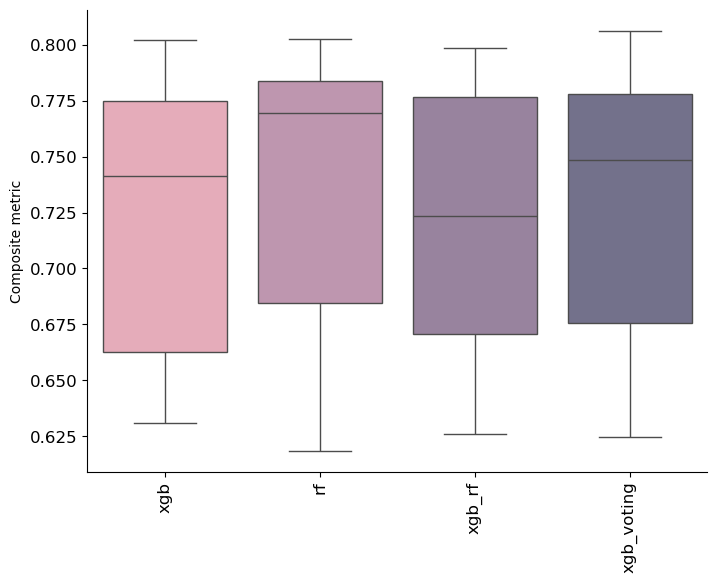

In [ ]:
model_1 = extract_metrics(model1_classifier,model1_regressor, 'model 1')
model_2 = extract_metrics(model2_classifier,model2_regressor, 'model 2')
model_3 = extract_metrics(model3_classifier,model3_regressor, 'model 3')
model_4 = extract_metrics(model4_classifier,model4_regressor, 'model 4')
dfs = [model_1, model_2, model_3, model_4]
dt = pd.concat(dfs, ignore_index=True)
model_1.to_csv("data/plot_metrics/model1.csv")
model_2.to_csv("data/plot_metrics/model2.csv")
model_3.to_csv("data/plot_metrics/model3.csv")
model_4.to_csv("data/plot_metrics/model4.csv")
# melt for plotting
heatmap_df = dt.melt(
    id_vars=['model', 'Dataset'],
    value_vars=['geometric_mean'],  # equivalent to measure.vars=23
    var_name='metric',
    value_name='value'
)

# map Dataset names
dataset_labels = [
    "Brain (AD)",
    "Brain (GL)",
    "Breast Cancer",
    "Lung",
    "Lung (High-Res)",
    "Lymph Node",
    "Ovarian",
    "Pancreas",
    "Skin"
]
heatmap_df['Dataset'] = pd.Categorical(
    heatmap_df['Dataset'],
    categories=dt['Dataset'].unique(),
    ordered=True
)
heatmap_df['Dataset'].cat.rename_categories(dataset_labels, inplace=True)

# map model names
model_labels = ["Model 1", "Model 2", "Model 3", "Model 4"]
heatmap_df['model'] = pd.Categorical(
    heatmap_df['model'],
    categories=dt['model'].unique(),
    ordered=True
)
heatmap_df['model'].cat.rename_categories(model_labels, inplace=True)

# colors
colors = ["#eea3b5", "#c58fb0", "#9a7ea3", "#6f6d8f"]

# plot
plt.figure(figsize=(8,6))
sns.boxplot(data=heatmap_df, x='model', y='value', palette=colors)
plt.xlabel('')
plt.ylabel('Composite metric')
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
sns.despine()
plt.show()
